# Combined Model deconvolution with config types

June 13, 2024

## Goal:
Deconvolve with config_type parameter and copy number correciton

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [16]:
from src.CopyNumberCorrection import load_expression_copy_correction
from src.ChromatinCopyNumberCorrector import load_chromatin_copy_correction

In [102]:
from src.config import load_combined_gene_expression_by_config_type, load_configs_by_config_type

config_type = 'distinct'
combined_gene_expression_config = load_combined_gene_expression_by_config_type(config_type,
    with_copy_correction=True)
chrom_config1, chrom_config2 = load_configs_by_config_type(config_type,
    with_copy_correction=True)


In [105]:
from src.model import Model
from src.combined_chromatin_model import CombinedChromatinModel

gene_name = 'CLB2'
combined_model = CombinedChromatinModel(chrom_config1, chrom_config2)
ge_model = Model(combined_gene_expression_config, gene_name)


Applying copy number correction


In [106]:
combined_model.load_combined_mnase_gene(gene_name)

Loading MNase reads for YPR119W/CLB2...Loading chromosome reads: 16
Done.
Applying copy number correction
(16, 340) (16,)
Loading MNase reads for YPR119W/CLB2...Loading chromosome reads: 16
Done.
Applying copy number correction
(15, 340) (15,)


In [107]:
ge_model.deconvolve_find_optimal_gamma()

In [143]:
combined_model.deconvolve(gamma=0.0066)

Deconvolving combined model with gamma=0.0066
Deconvolving bin size: 24x24
of G shape: (31, 340)
Deconvolving with gamma=0.0066
0/340 - 00:00:00.125
100/340 - 00:00:11.408
200/340 - 00:00:22.702
300/340 - 00:00:34.324
Deconvolved in : 00:00:40.163
The fitting norm is 13.68, the smoothing norm is: 34.91


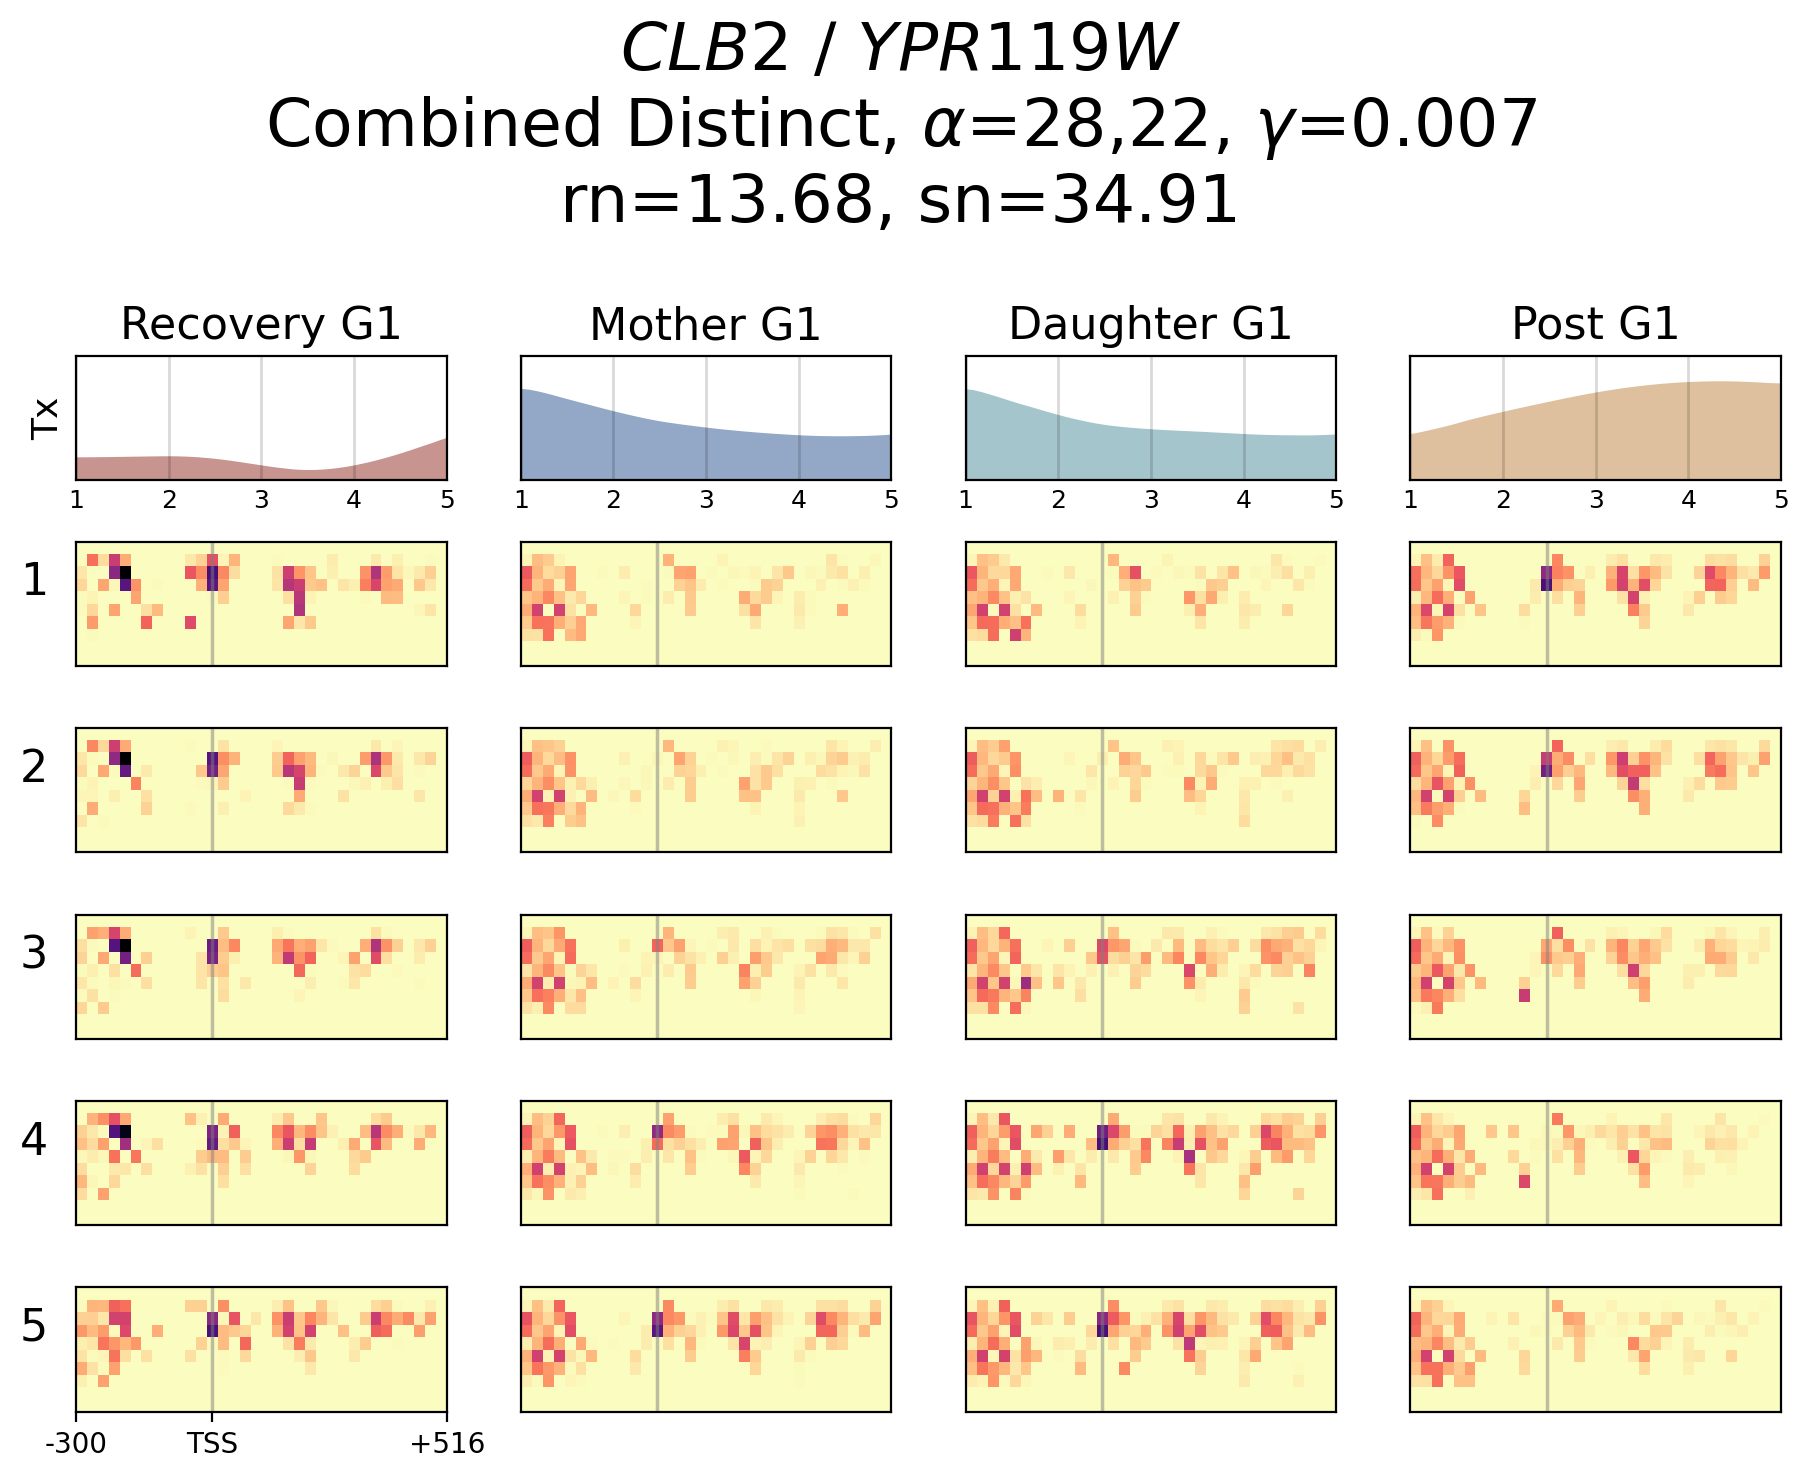

In [144]:
fig = combined_model.create_deconvolution_plots_abbreviated_flipped(ge_model)